<a href="https://colab.research.google.com/github/bigselorm/student-performance-predictor/blob/main/churm3s.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Columns:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: o

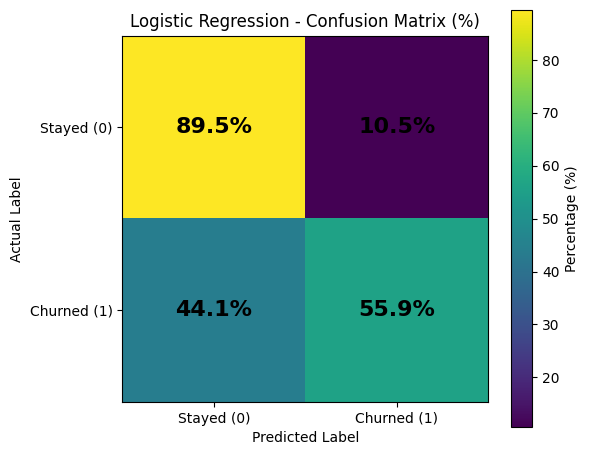

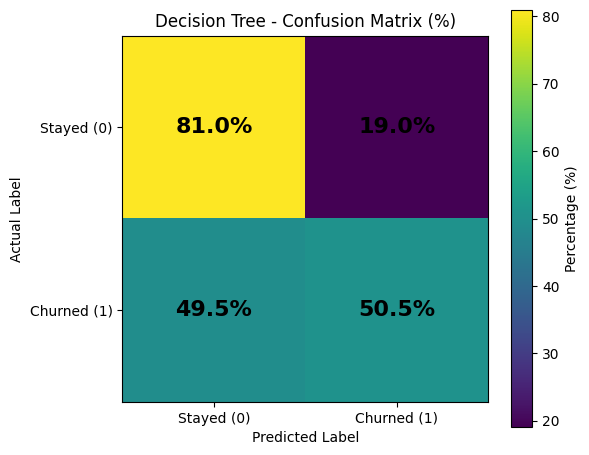

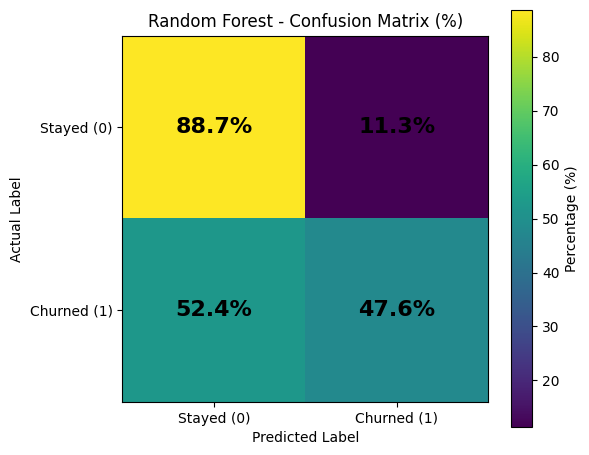

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.806,0.657,0.559,0.604
1,Decision Tree,0.729,0.490,0.505,0.497
2,Random Forest,0.778,0.603,0.476,0.532


In [6]:
import pandas as pd
import numpy as np

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
# Display column names
print("\nColumns:")
print(df.columns)

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())
print(df.describe())

# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Fill missing values in TotalCharges with the median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)
# Remove customerID
df = df.drop("customerID", axis=1)
# labeling the dataset
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

# Convert Yes and No into numbers
y = y.map({
    "No": 0,
    "Yes": 1
})
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Check missing values again
print(df.isnull().sum())


#label features
X = df.drop("Churn", axis=1)

# Target
y = df["Churn"]

# Convert Yes and No into numbers
y = y.map({
    "No": 0,
    "Yes": 1
})
# Numerical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

# Categorical columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print(y.value_counts())

from sklearn.preprocessing import OneHotEncoder

# Numerical preprocessing
numerical_transformer = StandardScaler()

# Categorical preprocessing
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# CREATE THE MODELS

logistic_model = LogisticRegression(
    max_iter=1000
)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# CREATE PIPELINES

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", logistic_model)
])


decision_tree_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", decision_tree_model)
])


random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", random_forest_model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


# TRAIN MODELS

logistic_pipeline.fit(X_train, y_train)

decision_tree_pipeline.fit(X_train, y_train)

random_forest_pipeline.fit(X_train, y_train)

# MAKE PREDICTIONS

logistic_pred = logistic_pipeline.predict(X_test)

decision_tree_pred = decision_tree_pipeline.predict(X_test)

random_forest_pred = random_forest_pipeline.predict(X_test)


# COMPARE PERFORMANCE


results = {

    "Logistic Regression": {
        "Accuracy": accuracy_score(y_test, logistic_pred),
        "Precision": precision_score(y_test, logistic_pred),
        "Recall": recall_score(y_test, logistic_pred),
        "F1 Score": f1_score(y_test, logistic_pred)
    },

    "Decision Tree": {
        "Accuracy": accuracy_score(y_test, decision_tree_pred),
        "Precision": precision_score(y_test, decision_tree_pred),
        "Recall": recall_score(y_test, decision_tree_pred),
        "F1 Score": f1_score(y_test, decision_tree_pred)
    },

    "Random Forest": {
        "Accuracy": accuracy_score(y_test, random_forest_pred),
        "Precision": precision_score(y_test, random_forest_pred),
        "Recall": recall_score(y_test, random_forest_pred),
        "F1 Score": f1_score(y_test, random_forest_pred)
    }
}

# DISPLAY RESULTS

results_df = pd.DataFrame(results).T

print("\nMODEL COMPARISON:")
print(results_df)
# Logistic Regression
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(y_test, logistic_pred))


# Decision Tree
print("\nDecision Tree Confusion Matrix:")
print(confusion_matrix(y_test, decision_tree_pred))


# Random Forest
print("\nRandom Forest Confusion Matrix:")
print(confusion_matrix(y_test, random_forest_pred))

from sklearn.metrics import confusion_matrix

print("Logistic Regression")
print(confusion_matrix(y_test, logistic_pred))

print("\nDecision Tree")
print(confusion_matrix(y_test, decision_tree_pred))

print("\nRandom Forest")
print(confusion_matrix(y_test, random_forest_pred))
import matplotlib.pyplot as plt
import numpy as np

# Your confusion matrices
matrices = {
    "Logistic Regression": confusion_matrix(y_test, logistic_pred),
    "Decision Tree": confusion_matrix(y_test, decision_tree_pred),
    "Random Forest": confusion_matrix(y_test, random_forest_pred)
}
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

models = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "Random Forest": random_forest_pred
}

for name, predictions in models.items():

    # Get confusion matrix
    cm = confusion_matrix(y_test, predictions)

    # Convert each row to percentages
    cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100

    # Plot
    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(cm_percent)

    ax.set_title(f"{name} - Confusion Matrix (%)")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Stayed (0)", "Churned (1)"])

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Stayed (0)", "Churned (1)"])

    # Add percentages inside boxes
    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm_percent[i, j]:.1f}%",
                ha="center",
                va="center",
                fontsize=16,
                fontweight="bold"
            )

    plt.colorbar(im, label="Percentage (%)")
    plt.tight_layout()
    plt.show()

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Predictions
y_pred_log = logistic_pipeline.predict(X_test)
y_pred_dt = decision_tree_pipeline.predict(X_test)
y_pred_rf = random_forest_pipeline.predict(X_test)

# Create comparison table
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

# Round the values
results[["Accuracy", "Precision", "Recall", "F1 Score"]] = \
    results[["Accuracy", "Precision", "Recall", "F1 Score"]].round(3)

results